# **Experiment: Interpreting Russian Case Relations with word2vec (PCA/LDA)**



## Data Loading

In [1]:
!curl -O https://raw.githubusercontent.com/UniversalDependencies/UD_Russian-SynTagRus/refs/heads/master/ru_syntagrus-ud-train-b.conllu

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 41.5M  100 41.5M    0     0  24.8M      0  0:00:01  0:00:01 --:--:-- 24.8M


In [2]:
with open('ru_syntagrus-ud-train-b.conllu', 'r', encoding='utf-8') as f:
        data = f.read()

In [3]:
import pandas as pd

In [4]:
def parse_conllu_manual(file_path):
    tokens = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()

            # skip empty lines and comments
            if not line or line.startswith('#'):
              continue

            # split by tab
            parts = line.split('\t')

            token = {
                'ID': parts[0],
                'FORM': parts[1],
                'LEMMA': parts[2],
                'POS': parts[3], # part-of-speech tag
                'FEATS': parts[5], # grammatical features
            }
            tokens.append(token)

    return pd.DataFrame(tokens)

In [5]:
df = parse_conllu_manual('ru_syntagrus-ud-train-b.conllu')
df.head(10)

,ID,FORM,LEMMA,POS,FEATS
0,1,Премьер-министр,премьер-министр,NOUN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing
1,2,РФ,РФ,PROPN,Abbr=Yes|NameType=Geo
2,3,Владимир,Владимир,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|NameType=Giv...
3,4,Путин,Путин,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|NameType=Sur...
4,5,подписал,подписать,VERB,Aspect=Perf|Gender=Masc|Mood=Ind|Number=Sing|T...
5,6,распоряжение,распоряжение,NOUN,Animacy=Inan|Case=Acc|Gender=Neut|Number=Sing
6,7,о,о,ADP,_
7,8,переводе,перевод,NOUN,Animacy=Inan|Case=Loc|Gender=Masc|Number=Sing
8,9,Государственного,государственный,ADJ,Case=Gen|Degree=Pos|Gender=Masc|Number=Sing
9,10,университета,университет,NOUN,Animacy=Inan|Case=Gen|Gender=Masc|Number=Sing


## Exploratory Data Analysis: Case Distribution

In [6]:
syntagrus_nouns = df[(df['POS'] == 'NOUN') | (df['POS'] == 'PROPN')]
syntagrus_nouns.shape

(126837, 5)

There are 126837 nouns in the dataset. Let's see their case distribution.

In [7]:
# extracting case from feats into a separate column
syntagrus_nouns.loc[:, 'CASE'] = syntagrus_nouns['FEATS'].str.extract(r'Case=([A-Za-z][A-Za-z]*)')
syntagrus_nouns['CASE'] = syntagrus_nouns['CASE'].fillna('none')

/tmp/ipykernel_1011/17843734.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  syntagrus_nouns.loc[:, 'CASE'] = syntagrus_nouns['FEATS'].str.extract(r'Case=([A-Za-z][A-Za-z]*)')
/tmp/ipykernel_1011/17843734.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  syntagrus_nouns['CASE'] = syntagrus_nouns['CASE'].fillna('none')


In [8]:
syntagrus_nouns.head()

,ID,FORM,LEMMA,POS,FEATS,CASE
0,1,Премьер-министр,премьер-министр,NOUN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing,Nom
1,2,РФ,РФ,PROPN,Abbr=Yes|NameType=Geo,none
2,3,Владимир,Владимир,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|NameType=Giv...,Nom
3,4,Путин,Путин,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|NameType=Sur...,Nom
5,6,распоряжение,распоряжение,NOUN,Animacy=Inan|Case=Acc|Gender=Neut|Number=Sing,Acc


In [9]:
syntagrus_nouns['CASE'].value_counts()

,count
CASE,
Gen,42116
Nom,31712
Acc,20641
Loc,13764
Ins,9610
Dat,6745
none,2204
Par,42
Voc,3


In [10]:
syntagrus_nouns[syntagrus_nouns['CASE'] == 'none'].head()

,ID,FORM,LEMMA,POS,FEATS,CASE
1,2,РФ,РФ,PROPN,Abbr=Yes|NameType=Geo,none
15,16,ГУ-ВШЭ,ГУ-ВШЭ,PROPN,Abbr=Yes|NameType=Com,none
23,24,РФ,РФ,PROPN,Abbr=Yes|NameType=Geo,none
29,5,ГУ-ВШЭ,ГУ-ВШЭ,PROPN,Abbr=Yes|NameType=Com,none
57,1,ВШЭ,ВШЭ,PROPN,Abbr=Yes|NameType=Com,none


In [11]:
# nouns with without a case tag are mostly abbreviations; we will filter them out
syntagrus_nouns = syntagrus_nouns[syntagrus_nouns['CASE'] !='none']

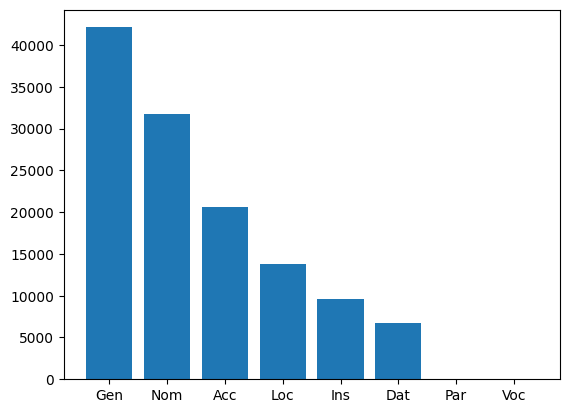

In [12]:
import matplotlib.pyplot as plt

plt.bar(syntagrus_nouns['CASE'].value_counts().index, syntagrus_nouns['CASE'].value_counts().values)
plt.show()

In [13]:
percentages = round(syntagrus_nouns['CASE'].value_counts(normalize=True) * 100, 4)
percentages

,proportion
CASE,
Gen,33.7920
Nom,25.4443
Acc,16.5614
Loc,11.0436
Ins,7.7106
Dat,5.4119
Par,0.0337
Voc,0.0024


**Strong imbalance** in the representation of case categories. There is a significant predominance of the *genitive* case – 33.8%. Among the "main" cases, the *dative* is the least represented in the corpus – 5.4%. *Partitive and vocative* forms account for less than 1% of all wordforms.

## Data Preprocessing

In [14]:
len(df)

445322

In [15]:
# delete punctuation
df = df[df['POS'] != 'PUNCT']
df = df.reset_index(drop=True)

In [16]:
len(df)

365334

Instead of vectorizing raw forms, we concatenate each form with its morphological tag (`form_grammeme`). This captures grammatical features. The original DataFrame is transformed accordingly.

In [17]:
df['FORM+TAGS'] = df['FORM'] + '_' + df['POS'] + '_' + df['FEATS']
df.head(3)

,ID,FORM,LEMMA,POS,FEATS,FORM+TAGS
0,1,Премьер-министр,премьер-министр,NOUN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing,Премьер-министр_NOUN_Animacy=Anim|Case=Nom|Gen...
1,2,РФ,РФ,PROPN,Abbr=Yes|NameType=Geo,РФ_PROPN_Abbr=Yes|NameType=Geo
2,3,Владимир,Владимир,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|NameType=Giv...,Владимир_PROPN_Animacy=Anim|Case=Nom|Gender=Ma...


Now we will add a `SENTENCE_ID` column that stores the ID of the sentence to which each word belongs. Then we will use this ID to create a `SENT_WITH_TAGS` column containing the full sentences (formed from tokens with their tags).

In [18]:
sent_id = 0
for index, row in df.iterrows():
  if row['ID'] == '1':
    sent_id += 1
  df.loc[index, 'SENTENCE_ID'] = f's{sent_id}'

In [19]:
df['SENT_WITH_TAGS'] = df.groupby('SENTENCE_ID')['FORM+TAGS'].transform(lambda x: ' '.join(x))

In [20]:
import nltk
nltk.download("punkt_tab")

def clean_text(text, tokenizer):
  text = text.lower()
  tokens = tokenizer(text)
  return tokens

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [21]:
docs = df["SENT_WITH_TAGS"].drop_duplicates().tolist()
tokens = list(map(lambda x: clean_text(x, nltk.word_tokenize), docs))

## Training Word2vec

In [22]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.6 MB/s eta 0:00:00


In [23]:
from gensim.models import Word2Vec
syntagrus_model = Word2Vec(sentences=tokens, vector_size=300, window=5, min_count=2, sg=0) # CBOW
len(syntagrus_model.wv)

30953

In [24]:
syntagrus_model.wv.most_similar('школы_Noun_animacy=inan|Case=Gen|Gender=Fem|Number=Sing'.lower())

[('страны_noun_animacy=inan|case=gen|gender=fem|number=sing',
  0.99982750415802),
 ('совета_noun_animacy=inan|case=gen|gender=masc|number=sing',
  0.9998232126235962),
 ('государственной_adj_case=gen|degree=pos|gender=fem|number=sing',
  0.9998090267181396),
 ('развития_noun_animacy=inan|case=gen|gender=neut|number=sing',
  0.9998055696487427),
 ('органов_noun_animacy=inan|case=gen|gender=masc|number=plur',
  0.9998013973236084),
 ('председатель_noun_animacy=anim|case=nom|gender=masc|number=sing',
  0.9997988343238831),
 ('несколько_num_animacy=inan|case=acc|numform=word|numtype=card',
  0.9997937679290771),
 ('спорта_noun_animacy=inan|case=gen|gender=masc|number=sing',
  0.9997884035110474),
 ('заседании_noun_animacy=inan|case=loc|gender=neut|number=sing',
  0.9997801780700684),
 ('своей_det_case=gen|gender=fem|number=sing|poss=yes|prontype=prs|reflex=yes',
  0.9997760653495789)]

In [25]:
syntagrus_model.wv.similarity('школы_Noun_animacy=inan|Case=Gen|Gender=Fem|Number=Sing'.lower(), 'министерства_Noun_Animacy=Inan|Case=Gen|Gender=Neut|number=sing'.lower())

np.float32(0.998671)

In [26]:
# коллокаты
import re

for t in syntagrus_model.wv.most_similar(positive=[u'школы_Noun_animacy=inan|Case=Gen|Gender=Fem|Number=Sing'.lower()], topn=10):
  cond = re.search(r'|case=nom', t[0])
  if cond != None:
    print (t[0], t[1])

страны_noun_animacy=inan|case=gen|gender=fem|number=sing 0.99982750415802
совета_noun_animacy=inan|case=gen|gender=masc|number=sing 0.9998232126235962
государственной_adj_case=gen|degree=pos|gender=fem|number=sing 0.9998090267181396
развития_noun_animacy=inan|case=gen|gender=neut|number=sing 0.9998055696487427
органов_noun_animacy=inan|case=gen|gender=masc|number=plur 0.9998013973236084
председатель_noun_animacy=anim|case=nom|gender=masc|number=sing 0.9997988343238831
несколько_num_animacy=inan|case=acc|numform=word|numtype=card 0.9997937679290771
спорта_noun_animacy=inan|case=gen|gender=masc|number=sing 0.9997884035110474
заседании_noun_animacy=inan|case=loc|gender=neut|number=sing 0.9997801780700684
своей_det_case=gen|gender=fem|number=sing|poss=yes|prontype=prs|reflex=yes 0.9997760653495789


In [27]:
# поиск лишнего слова по смыслу : 2 генитива и 1 номинатив - выбрал номинатив в качестве лишнего
syntagrus_model.wv.doesnt_match('школы_Noun_animacy=inan|Case=Gen|Gender=Fem|Number=Sing университет_noun_Animacy=Inan|Case=Nom|Gender=Masc|Number=Sing министерства_Noun_Animacy=Inan|Case=Gen|Gender=Neut|number=sing'.lower().split())

'университет_noun_animacy=inan|case=nom|gender=masc|number=sing'

In [28]:
# 2 аккузатива и 1 номинатив - выбрал аккузатив в качестве лишнего
syntagrus_model.wv.doesnt_match('отделение_Noun_Animacy=Inan|Case=Acc|Gender=Neut|Number=Sing группа_Noun_Animacy=Inan|Case=Nom|Gender=Fem|Number=Sing возможность_noun_Animacy=Inan|Case=Acc|Gender=Fem|Number=Sing'.lower().split())

'отделение_noun_animacy=inan|case=acc|gender=neut|number=sing'

## Dimensionality Reduction (PCA, LDA) and Visualization

###  PCA — Principal Component Analysis

In [29]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import numpy as np

In [38]:
import re
case_pattern = re.compile(r'case=(\w+)')

In [42]:
noun_tokens = [word for word in syntagrus_model.wv.index_to_key
               if ('noun_' in word.lower() or 'propn_' in word.lower())
               and case_pattern.search(word) and 'voc' not in word and 'par' not in word]
# filtering out the partitive and vocative as together make up less than 1% of the dataset.

In [43]:
# getting embeddings for nouns only
word_vectors = syntagrus_model.wv[noun_tokens]

# reducing dimensionality to 3D
pca = PCA(n_components=3)
result_3d = pca.fit_transform(word_vectors)

In [44]:
def get_case(token):
    for case in ['nom', 'gen', 'dat', 'acc', 'ins', 'loc', 'par', 'voc']:
        if f'case={case}' in token:
            return case

In [45]:
cases = [get_case(token) for token in noun_tokens if get_case(token) not in ['par', 'voc', None]]

In [34]:
!pip install plotly

In [35]:
import plotly.graph_objects as go
import plotly.express as px

In [36]:
color_map = {
    'nom': 'red',
    'gen': 'blue',
    'dat': 'green',
    'acc': 'orange',
    'ins': 'purple',
    'loc': 'brown',
}
colors = [color_map[case] for case in cases]

In [63]:
fig = go.Figure()

unique_cases = sorted(set(cases))
for case in unique_cases:
    mask = [c == case for c in cases]
    x_case = result_3d[mask, 0]
    y_case = result_3d[mask, 1]
    z_case = result_3d[mask, 2]
    tokens_case = [noun_tokens[i] for i, m in enumerate(mask) if m]

    fig.add_trace(go.Scatter3d(
        x=x_case,
        y=y_case,
        z=z_case,
        mode='markers',
        marker=dict(
            size=5,
            color=color_map.get(case, 'gray'),
            opacity=0.8
        ),
        text=tokens_case,
        hoverinfo='text',
        name=case.upper()
    ))

fig.update_layout(
    title="Noun Embeddings Colored by Grammatical Case",
    scene=dict(
        xaxis_title='PCA Component 1',
        yaxis_title='PCA Component 2',
        zaxis_title='PCA Component 3',
        aspectmode='cube'
    ),
    width=1000,
    height=700
)

fig.show()

### LDA - Linear Discriminant Analysis

In [50]:
vectors = syntagrus_model.wv.vectors
tokens = syntagrus_model.wv.index_to_key

In [52]:
X_list = []
y_list = []

for token, vec in zip(tokens, vectors):

    case_match = case_pattern.search(token)
    if 'noun' not in token or not case_match or 'par' in token or 'voc' in token:
        continue

    case = case_match.group(1)

    X_list.append(vec)
    y_list.append(case)

X = np.array(X_list)
y = np.array(y_list)

In [53]:
X.shape

(13626, 300)

In [54]:
y.shape

(13626,)

In [55]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [56]:
lda = LinearDiscriminantAnalysis(n_components=3)
X_r3 = lda.fit(X, y).transform(X)

In [57]:
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
target_names = ['NOM', 'GEN', 'ACC', 'DAT', 'INS', 'LOC']
unique_cases = np.unique(y)

In [65]:
data = []

for color, case, target_name in zip(colors, unique_cases, target_names):

    mask = y == case

    x_vals = X_r3[mask, 0]
    y_vals = X_r3[mask, 1]
    z_vals = X_r3[mask, 2]

    tokens_case = [noun_tokens[i] for i, m in enumerate(mask) if m]

    trace = go.Scatter3d(
        x=x_vals,
        y=y_vals,
        z=z_vals,
        mode='markers',
        marker=dict(
            color=color,
            size=5,
            opacity=0.8
        ),
        name=target_name,
        text=tokens_case,
        hoverinfo='text',
    )
    data.append(trace)

layout = go.Layout(
    title='Noun Embeddings Colored by Grammatical Case',
    scene=dict(
        xaxis_title='X axis',
        yaxis_title='Y axis',
        zaxis_title='Z axis',
        aspectmode='cube'
    ),
    width=800,
    height=600,
    legend=dict(
        x=0.8, y=0.9,
        bordercolor='black',
        borderwidth=1
    )
)

fig = go.Figure(data=data, layout=layout)
fig.show()